In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)

# Load the resolved dataset
df = pd.read_csv("../data/fda_resolved.csv")

print(f"✅ Data Loaded — {df.shape[0]:,} records")

✅ Data Loaded — 14,746 records


In [3]:
# Group A — Class I recalls (most dangerous)
group_a = df[df['classification'] == 'Class I']['resolution_days']

# Group B — Class II recalls (moderate)
group_b = df[df['classification'] == 'Class II']['resolution_days']

print("=== Group A — Class I ===")
print(f"Count   : {len(group_a):,}")
print(f"Mean    : {group_a.mean():.0f} days")
print(f"Std Dev : {group_a.std():.0f} days")

print("\n=== Group B — Class II ===")
print(f"Count   : {len(group_b):,}")
print(f"Mean    : {group_b.mean():.0f} days")
print(f"Std Dev : {group_b.std():.0f} days")

print(f"\nDifference in means : {group_a.mean() - group_b.mean():.0f} days")

=== Group A — Class I ===
Count   : 1,464
Mean    : 968 days
Std Dev : 501 days

=== Group B — Class II ===
Count   : 11,778
Mean    : 651 days
Std Dev : 466 days

Difference in means : 316 days


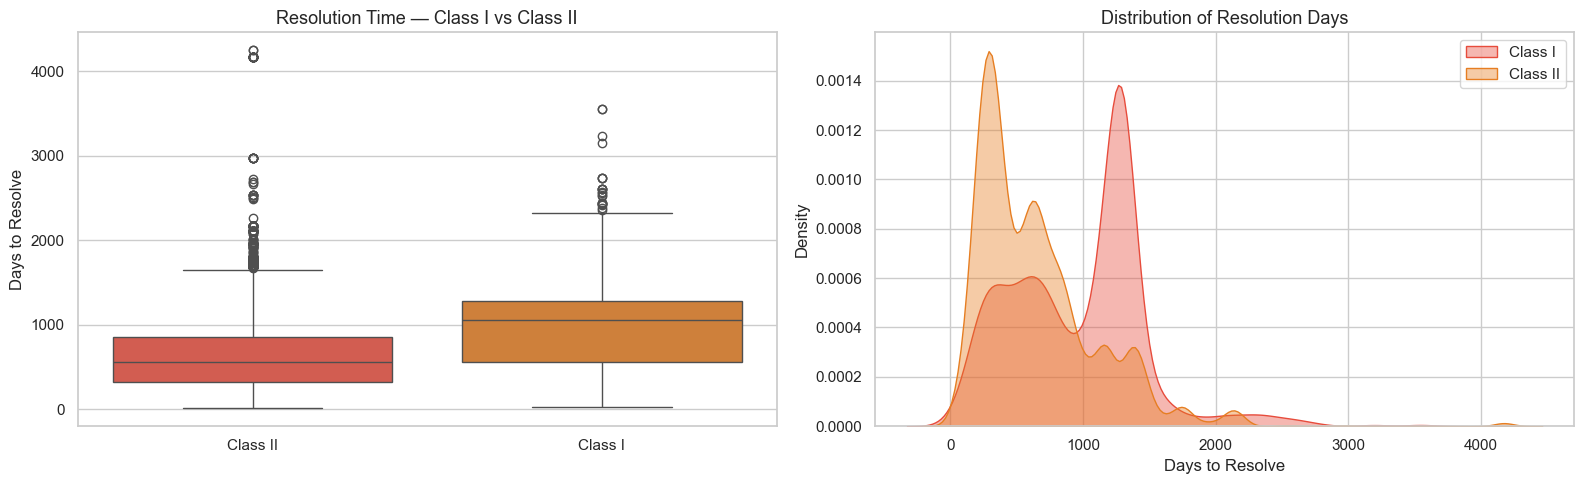

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot
sns.boxplot(
    data=df[df['classification'].isin(['Class I', 'Class II'])],
    x='classification', y='resolution_days',
    palette=['#e74c3c', '#e67e22'], ax=axes[0]
)
axes[0].set_title('Resolution Time — Class I vs Class II', fontsize=13)
axes[0].set_ylabel('Days to Resolve')
axes[0].set_xlabel('')

# Distribution plot
sns.kdeplot(group_a, ax=axes[1], label='Class I', 
            color='#e74c3c', fill=True, alpha=0.4)
sns.kdeplot(group_b, ax=axes[1], label='Class II', 
            color='#e67e22', fill=True, alpha=0.4)
axes[1].set_title('Distribution of Resolution Days', fontsize=13)
axes[1].set_xlabel('Days to Resolve')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/05_group_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
from scipy.stats import ttest_ind

# Run two sample t-test (z-test for large samples)
t_stat, p_value = ttest_ind(group_a, group_b, equal_var=False)


print("\n      FREQUENTIST A/B TEST RESULTS")
print(f"\nGroup A (Class I)  Mean : {group_a.mean():.0f} days")
print(f"Group B (Class II) Mean : {group_b.mean():.0f} days")
print(f"\nDifference         Mean : {group_a.mean() - group_b.mean():.0f} days")
print(f"T-Statistic              : {t_stat:.4f}")
print(f"P-Value                  : {p_value:.10f}")

if p_value < 0.05:
    print("\n   RESULT : Statistically Significant")
    print("   The difference is REAL — not due to chance")
else:
    print("\n RESULT : Not Statistically Significant")
    print("   Cannot prove the difference is real")


      FREQUENTIST A/B TEST RESULTS

Group A (Class I)  Mean : 968 days
Group B (Class II) Mean : 651 days

Difference         Mean : 316 days
T-Statistic              : 22.9749
P-Value                  : 0.0000000000

   RESULT : Statistically Significant
   The difference is REAL — not due to chance


Class I drug recalls take on average 316 days longer to resolve than Class II recalls and we are 99.99% certain this is a real difference, not random chance

In [17]:
import scipy.stats as stats

# Calculate 95% confidence interval for the difference
diff = group_a.mean() - group_b.mean()
se = np.sqrt(group_a.var()/len(group_a) + group_b.var()/len(group_b))
ci_lower = diff - 1.96 * se
ci_upper = diff + 1.96 * se

print("\n         95% CONFIDENCE INTERVAL")
print(f"Mean Difference : {diff:.0f} days")
print(f"Lower Bound     : {ci_lower:.0f} days")
print(f"Upper Bound     : {ci_upper:.0f} days")
print(f"\nWe are 95% confident the true difference")
print(f"is between {ci_lower:.0f} and {ci_upper:.0f} days")


         95% CONFIDENCE INTERVAL
Mean Difference : 316 days
Lower Bound     : 289 days
Upper Bound     : 343 days

We are 95% confident the true difference
is between 289 and 343 days


In [22]:
#Power Analysis
from statsmodels.stats.power import TTestIndPower

# Power analysis
effect_size = (group_a.mean() - group_b.mean()) / np.sqrt(
    (group_a.std()**2 + group_b.std()**2) / 2
)

analysis = TTestIndPower()
power = analysis.solve_power(
    effect_size=effect_size,
    nobs1=len(group_a),
    alpha=0.05,
    alternative='two-sided'
)

print("\n           POWER ANALYSIS")
print(f"Effect Size : {effect_size:.4f}")
print(f"Sample Size : {len(group_a):,} (Class I)")
print(f"Alpha       : 0.05")
print(f"Power       : {power:.4f}")
if power >= 0.80:
    print(" Power is sufficient (>= 0.80)")
    print(" Our sample size is large enough")
else:
    print(" Power is low — sample size too small")


           POWER ANALYSIS
Effect Size : 0.6541
Sample Size : 1,464 (Class I)
Alpha       : 0.05
Power       : 1.0000
 Power is sufficient (>= 0.80)
 Our sample size is large enough


In [24]:
#Final Frequentist Summary Table
summary = pd.DataFrame({
    'Metric': [
        'Group A (Class I) Mean',
        'Group B (Class II) Mean',
        'Difference',
        'T-Statistic',
        'P-Value',
        'CI Lower (95%)',
        'CI Upper (95%)',
        'Effect Size',
        'Power',
        'Result'
    ],
    'Value': [
        f'{group_a.mean():.0f} days',
        f'{group_b.mean():.0f} days',
        f'{group_a.mean() - group_b.mean():.0f} days',
        f'{t_stat:.4f}',
        f'{p_value:.10f}',
        f'{ci_lower:.0f} days',
        f'{ci_upper:.0f} days',
        f'{effect_size:.4f}',
        f'{power:.4f}',
        ' Statistically Significant'
    ]
})

summary.style.set_properties(**{
    'text-align': 'left',
    'font-size': '13px'
}).hide(axis='index')

Metric,Value
Group A (Class I) Mean,968 days
Group B (Class II) Mean,651 days
Difference,316 days
T-Statistic,22.9749
P-Value,0.0000000000
CI Lower (95%),289 days
CI Upper (95%),343 days
Effect Size,0.6541
Power,1.0000
Result,Statistically Significant


Class I recalls take 316 days longer than Class II this is statistically proven with a p-value of essentially zero and 100% statistical power